# 05 · Collaboration Network (co-PI Analysis)

**Goal:** Build and analyze the co-PI collaboration graph.

Sections:
1. Setup & data load
2. Build co-PI graph with `networkx`
3. Node-level metrics (degree, betweenness, PageRank)
4. Community detection (Louvain / greedy modularity)
5. Cross-college vs intra-college collaboration rates
6. Collaboration over time
7. Draft network visualizations
8. Export metrics CSV

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mc
import seaborn as sns
import networkx as nx
import plotly.graph_objects as go

pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid')

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / 'data' / 'processed').exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
PROCESSED_DIR = REPO_ROOT / 'data' / 'processed'
OUTPUTS_DIR   = REPO_ROOT / 'outputs'
OUTPUTS_DIR.mkdir(exist_ok=True)
print('networkx version:', nx.__version__)

networkx version: 3.5


In [2]:
faculty       = pd.read_parquet(PROCESSED_DIR / 'faculty.parquet')
grants        = pd.read_parquet(PROCESSED_DIR / 'grants.parquet')
faculty_grants = pd.read_parquet(PROCESSED_DIR / 'faculty_grants.parquet')

print(f'faculty_grants: {faculty_grants.shape}')
print(faculty_grants.head(3))

faculty_grants: (3144, 9)
  faculty_id  faculty_name grant_id  is_pi  is_copi source  hire_date  \
0    1018793  SUN, HONGWEI  1124530   True    False   both 2020-08-31   
1    1018793  SUN, HONGWEI  1126713   True    False   both 2020-08-31   
2    1018793  SUN, HONGWEI  1456220   True    False   both 2020-08-31   

  grant_startdate         neu_status  
0      2016-06-01  prior_institution  
1      2016-01-15  prior_institution  
2      2019-09-01  prior_institution  


## 1 · Build Co-PI Edge List

In [3]:
# Build co-PI pairs: all pairs of faculty who share a grant
# (regardless of PI/co-PI role — both are collaborators on the same grant)

# Keep one row per (grant_id, faculty_id)
# Drop null faculty IDs in all forms: actual NaN, and stringified 'nan'/'None'
_null_ids = {'nan', 'none', '', 'nat'}
gf_dedup = (faculty_grants
            .dropna(subset=['faculty_id'])
            .loc[lambda df: ~df['faculty_id'].astype(str).str.lower().isin(_null_ids)]
            .drop_duplicates(subset=['grant_id', 'faculty_id']))

# Self-join on grant_id to get all faculty pairs per grant
pairs = gf_dedup.merge(gf_dedup, on='grant_id', suffixes=('_a', '_b'))
pairs = pairs[pairs['faculty_id_a'] < pairs['faculty_id_b']]  # remove self + duplicates

print(f'Raw collaboration pairs (grant-level): {len(pairs):,}')
print(f'Unique faculty pairs:                  {pairs[["faculty_id_a", "faculty_id_b"]].drop_duplicates().shape[0]:,}')


Raw collaboration pairs (grant-level): 680
Unique faculty pairs:                  504


In [4]:
# Build edge weights: n_grants and total_dollars shared
grant_dollars = grants[['grant_id', 'totaldollars', 'startdateyear']].drop_duplicates('grant_id')
pairs = pairs.merge(grant_dollars, on='grant_id', how='left')

edges = (pairs.groupby(['faculty_id_a', 'faculty_id_b'])
         .agg(
             n_grants=('grant_id', 'nunique'),
             total_dollars=('totaldollars', 'sum'),
             first_year=('startdateyear', 'min'),
             last_year=('startdateyear', 'max'),
         )
         .reset_index())

print(f'Unique collaboration edges: {len(edges):,}')
print(f'Edge weight distribution (n_grants):'); print(edges['n_grants'].describe())

Unique collaboration edges: 504
Edge weight distribution (n_grants):
count    504.000000
mean       1.349206
std        0.887890
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        8.000000
Name: n_grants, dtype: float64


## 2 · Build NetworkX Graph & Attach Metadata

In [5]:
G = nx.Graph()

# Add nodes with attributes
# Build id → name and id → college maps
id_to_name   = faculty_grants.drop_duplicates('faculty_id').set_index('faculty_id')['faculty_name'].to_dict()
id_to_college = (faculty.dropna(subset=['faculty_id'])
                 .set_index('faculty_id')['superior_academic_unit'].to_dict())
# Supplement from lookup table

all_faculty_ids = set(edges['faculty_id_a']) | set(edges['faculty_id_b'])
for fid in all_faculty_ids:
    raw_college = id_to_college.get(fid)
    G.add_node(fid,
               name=id_to_name.get(fid, str(fid)),
               college=str(raw_college) if raw_college is not None else 'Unknown')

# Add edges
for _, row in edges.iterrows():
    G.add_edge(row['faculty_id_a'], row['faculty_id_b'],
               weight=int(row['n_grants']),
               dollars=float(row['total_dollars']))

print(f'Graph: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges')
print(f'Connected components: {nx.number_connected_components(G)}')
print(f'Density: {nx.density(G):.4f}')


Graph: 287 nodes, 504 edges
Connected components: 32
Density: 0.0123


## 3 · Node-Level Metrics

In [6]:
degree       = dict(G.degree(weight='weight'))
degree_unw   = dict(G.degree())
pagerank     = nx.pagerank(G, weight='weight')

# Betweenness on largest component (full graph can be slow)
Gcc = G.subgraph(max(nx.connected_components(G), key=len)).copy()
betweenness = nx.betweenness_centrality(Gcc, weight='weight', normalized=True)

node_metrics = pd.DataFrame({
    'faculty_id':  list(G.nodes),
    'name':        [G.nodes[n]['name']    for n in G.nodes],
    'college':     [G.nodes[n]['college'] for n in G.nodes],
    'degree_weighted': [degree[n]       for n in G.nodes],
    'degree_unweighted': [degree_unw[n] for n in G.nodes],
    'pagerank':    [pagerank[n]           for n in G.nodes],
    'betweenness': [betweenness.get(n, 0) for n in G.nodes],
}).sort_values('degree_weighted', ascending=False).reset_index(drop=True)

print('Top 20 most-connected faculty (weighted degree):')
display(node_metrics.head(20))

Top 20 most-connected faculty (weighted degree):


,faculty_id,name,college,degree_weighted,degree_unweighted,pagerank,betweenness
0,148296,"KAELI, DAVID R",College of Engineering,35,21,0.016761,0.290058
1,1793665,"MELODIA, TOMMASO",College of Engineering,32,16,0.014651,0.165109
2,141740,"ONDRECHEN, MARY JO",College of Science,20,12,0.010989,0.069757
3,141388,"DUGGAN, CLAIRE",Engineering,20,10,0.009283,0.017472
4,1793351,"ERGUN, OZLEM",College of Engineering,19,10,0.009110,0.050839
5,1759074,"MARSELLA, STACY C",Khoury College of Computer Sciences,19,9,0.008655,0.049520
6,141482,"ISAACS, JACKIE A",Engineering,19,12,0.009968,0.050772
7,1982335,"HARTEVELD, CASPER","College of Arts, Media and Design",19,11,0.009793,0.045668
8,141178,"DY, JENNIFER G",College of Engineering,17,13,0.008577,0.151329
9,1080747,"JORNET, JOSEP",College of Engineering,17,8,0.007561,0.006962


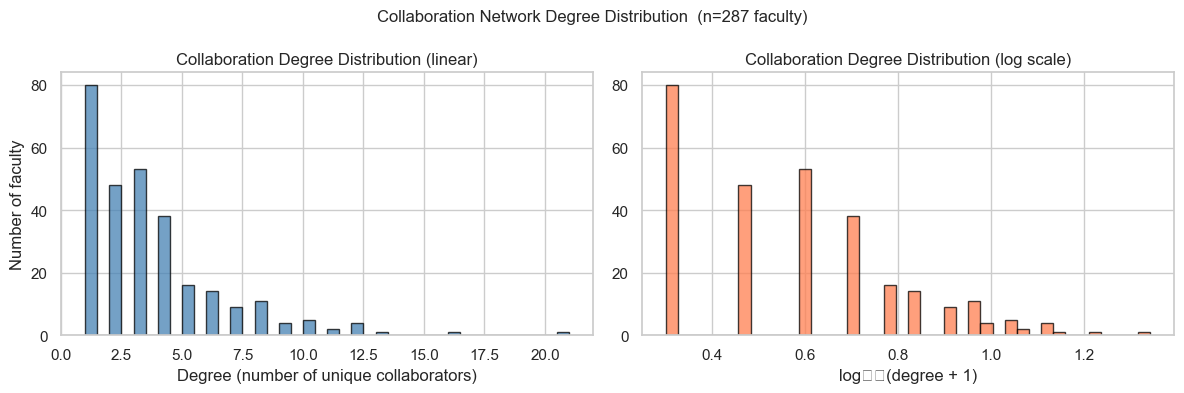

In [7]:
# Degree distribution
degs = [d for _, d in G.degree()]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(degs, bins=40, edgecolor='black', alpha=0.75, color='steelblue')
axes[0].set_xlabel('Degree (number of unique collaborators)')
axes[0].set_ylabel('Number of faculty')
axes[0].set_title('Collaboration Degree Distribution (linear)')

axes[1].hist([np.log10(d+1) for d in degs], bins=40, edgecolor='black', alpha=0.75, color='coral')
axes[1].set_xlabel('log₁₀(degree + 1)')
axes[1].set_title('Collaboration Degree Distribution (log scale)')

plt.suptitle(f'Collaboration Network Degree Distribution  (n={G.number_of_nodes():,} faculty)', fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'w7_degree_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

- Northeastern's collaboration network is moderately concentrated, with most faculty in small teams but a visible collaborative core connecting across research groups.
- 80+ faculty (28% of the network) work with only one other grant-funded colleague
  - This could indicate solo researchers or very specialized partnerships
  - Or it might reflect early-career faculty with limited network

## 4 · Community Detection

In [8]:
try:
    from community import community_louvain  # python-louvain package
    partition = community_louvain.best_partition(Gcc, weight='weight', random_state=42)
    method = 'Louvain'
except ImportError:
    # Fallback: greedy modularity (built-in networkx)
    communities_gen = nx.community.greedy_modularity_communities(Gcc, weight='weight')
    partition = {}
    for i, comm in enumerate(communities_gen):
        for node in comm:
            partition[node] = i
    method = 'Greedy Modularity'

n_communities = len(set(partition.values()))
print(f'Community detection method: {method}')
print(f'Number of communities found: {n_communities}')

# Attach community to node attributes
for node in Gcc.nodes:
    Gcc.nodes[node]['community'] = partition.get(node, -1)

# Community size distribution
comm_sizes = pd.Series(partition).value_counts().sort_index()
print('\nCommunity sizes (top 20):')
print(comm_sizes.head(20).to_string())

Community detection method: Louvain
Number of communities found: 11

Community sizes (top 20):
0     25
1     15
2     13
3     32
4     22
5     29
6     20
7     12
8     15
9     15
10    14


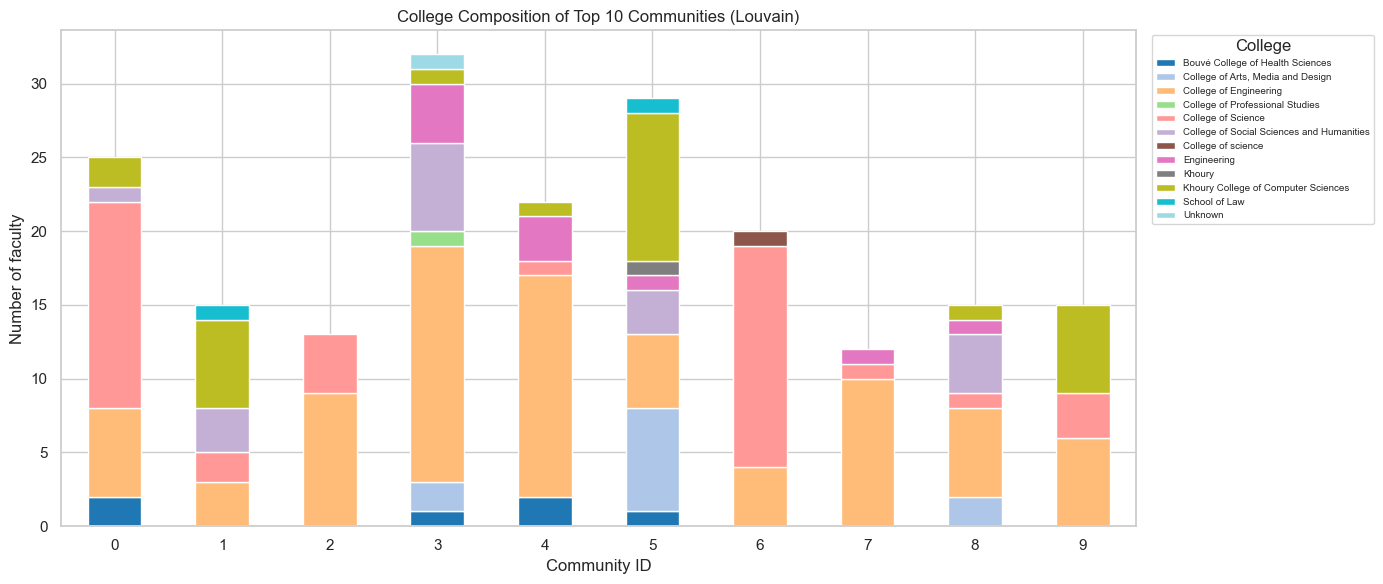

In [9]:
# College composition of each community (top 10 communities)
node_metrics_large = node_metrics[node_metrics['faculty_id'].isin(Gcc.nodes)].copy()
node_metrics_large['community'] = node_metrics_large['faculty_id'].map(partition)

top_comms = comm_sizes.head(10).index.tolist()
comm_college = (node_metrics_large[node_metrics_large['community'].isin(top_comms)]
                .groupby(['community', 'college'])
                .size()
                .unstack(fill_value=0))

fig, ax = plt.subplots(figsize=(14, 6))
comm_college.plot(kind='bar', stacked=True, ax=ax, colormap='tab20', edgecolor='white')
ax.set_xlabel('Community ID')
ax.set_ylabel('Number of faculty')
ax.set_title(f'College Composition of Top 10 Communities ({method})')
ax.legend(title='College', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'w7_community_college_composition.png', dpi=150, bbox_inches='tight')
plt.show()

## 5 · Cross-College vs Intra-College Collaboration

Collaboration edges with both sides mapped: 500
  Cross-college: 217 (43.4%)
  Intra-college: 283 (56.6%)


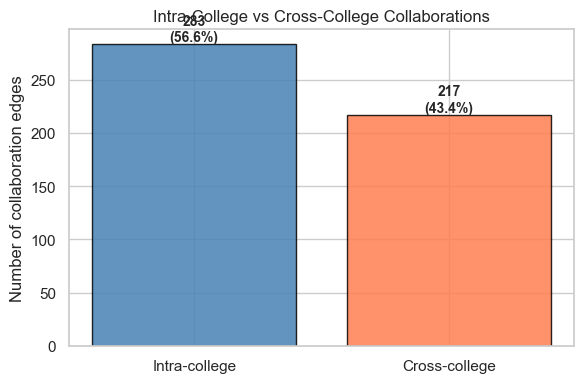

In [10]:
# Map colleges to edges
edges_full = edges.copy()
edges_full['college_a'] = edges_full['faculty_id_a'].map(id_to_college)
edges_full['college_b'] = edges_full['faculty_id_b'].map(id_to_college)

# Remove edges where either side is unmapped
edges_mapped = edges_full.dropna(subset=['college_a', 'college_b'])
edges_mapped = edges_mapped.copy()
edges_mapped['is_cross_college'] = edges_mapped['college_a'] != edges_mapped['college_b']

total_edges = len(edges_mapped)
cross_edges = edges_mapped['is_cross_college'].sum()
intra_edges = total_edges - cross_edges

print(f'Collaboration edges with both sides mapped: {total_edges:,}')
print(f'  Cross-college: {cross_edges:,} ({cross_edges/total_edges*100:.1f}%)')
print(f'  Intra-college: {intra_edges:,} ({intra_edges/total_edges*100:.1f}%)')

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Intra-college', 'Cross-college'], [intra_edges, cross_edges],
       color=['steelblue', 'coral'], edgecolor='black', alpha=0.85)
for i, v in enumerate([intra_edges, cross_edges]):
    ax.text(i, v + 3, f'{v:,}\n({v/total_edges*100:.1f}%)',
            ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('Number of collaboration edges')
ax.set_title('Intra-College vs Cross-College Collaborations')
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'w7_cross_intra_college.png', dpi=150, bbox_inches='tight')
plt.show()

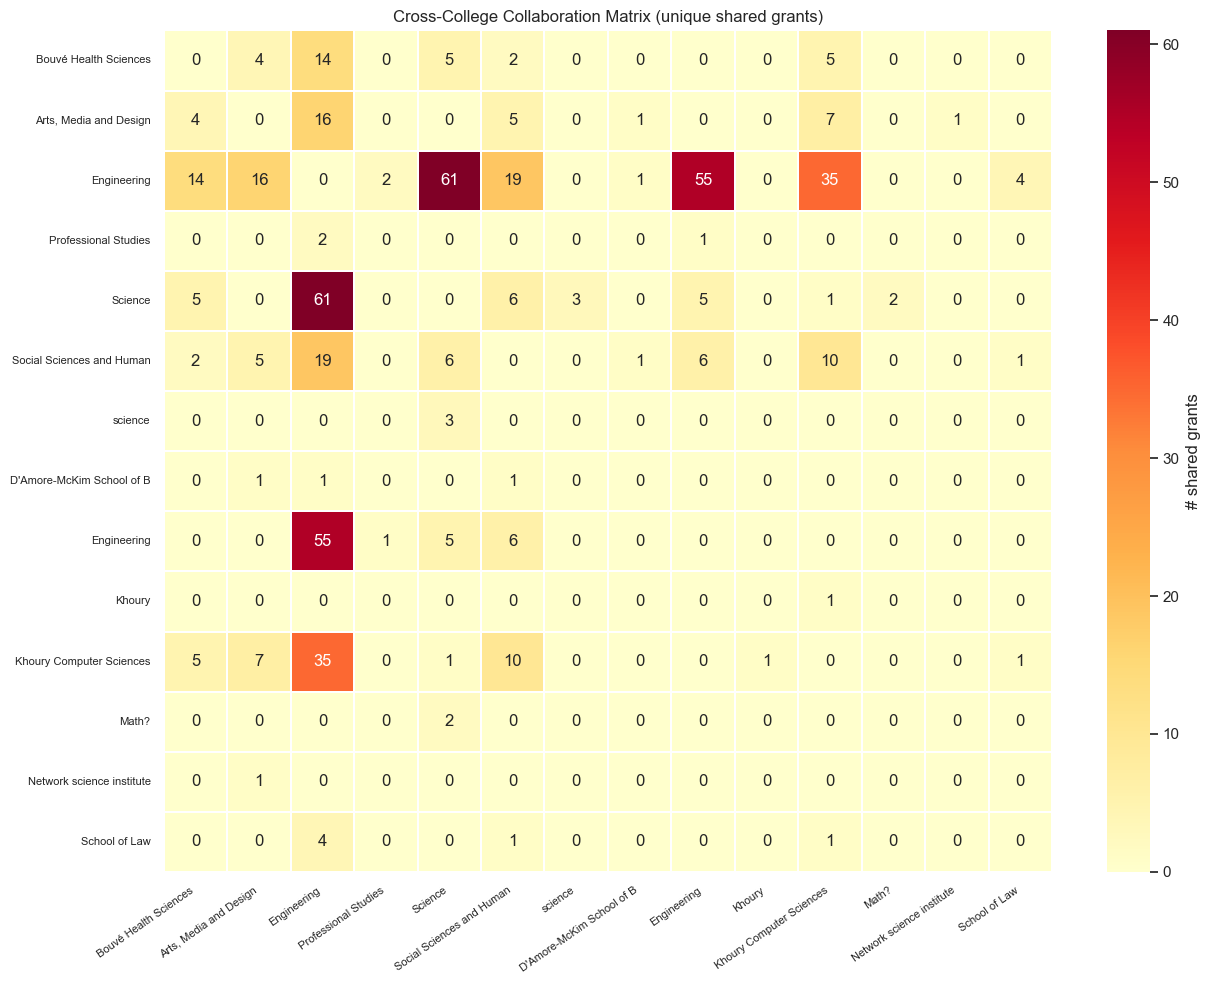

In [11]:
# Cross-college collaboration matrix
cross = edges_mapped[edges_mapped['is_cross_college']]
collab_matrix = (cross
                 .groupby(['college_a', 'college_b'])['n_grants']
                 .sum()
                 .unstack(fill_value=0))

# Symmetrize
all_cols = sorted(set(collab_matrix.index) | set(collab_matrix.columns))
collab_matrix = collab_matrix.reindex(index=all_cols, columns=all_cols, fill_value=0)
collab_matrix = collab_matrix + collab_matrix.T

short = lambda s: str(s).replace('College of ', '').replace('Northeastern University ', 'NU ')[:25]
collab_matrix.index   = [short(c) for c in collab_matrix.index]
collab_matrix.columns = [short(c) for c in collab_matrix.columns]

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(collab_matrix, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.3, ax=ax, cbar_kws={'label': '# shared grants'})
ax.set_title('Cross-College Collaboration Matrix (unique shared grants)')
plt.xticks(rotation=35, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'w7_cross_college_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 6 · Collaboration Over Time

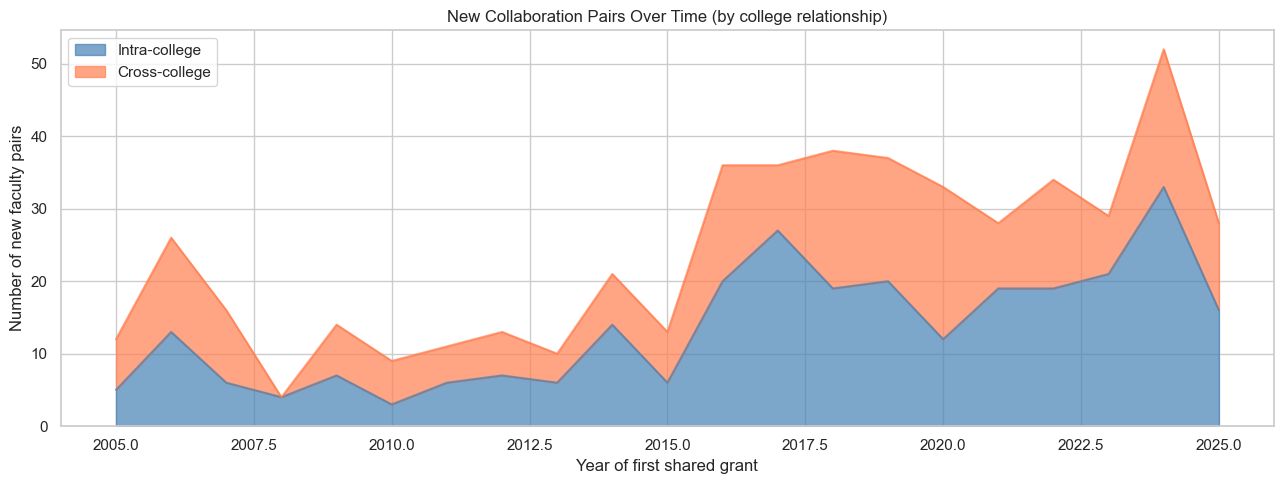

In [12]:
collab_yr = (edges_full
             .dropna(subset=['first_year'])
             .assign(year=lambda df: df['first_year'].astype(int))
             .query('2000 <= year <= 2025'))

collab_yr_mapped = collab_yr.dropna(subset=['college_a', 'college_b']).copy()
collab_yr_mapped['is_cross'] = collab_yr_mapped['college_a'] != collab_yr_mapped['college_b']

annual_collab = (collab_yr_mapped
                 .groupby(['year', 'is_cross'])
                 .agg(n_pairs=('n_grants', 'count'),
                      n_grants=('n_grants', 'sum'))
                 .reset_index())

pivot = annual_collab.pivot(index='year', columns='is_cross', values='n_pairs').fillna(0)
pivot.columns = ['Intra-college', 'Cross-college']

fig, ax = plt.subplots(figsize=(13, 5))
pivot.plot(kind='area', stacked=True, ax=ax, alpha=0.7,
           color=['steelblue', 'coral'])
ax.set_xlabel('Year of first shared grant')
ax.set_ylabel('Number of new faculty pairs')
ax.set_title('New Collaboration Pairs Over Time (by college relationship)')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'w7_collab_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

## 7 · Network Visualization (Plotly)

In [13]:
# Visualize the largest connected component, filtered to faculty with degree >= 3
# to keep the chart readable

G_viz = Gcc.copy()
low_degree = [n for n, d in G_viz.degree() if d < 3]
G_viz.remove_nodes_from(low_degree)
print(f'Visualization graph: {G_viz.number_of_nodes()} nodes, {G_viz.number_of_edges()} edges')

pos = nx.spring_layout(G_viz, seed=42, k=0.4)

# Assign a color per college
unique_colleges = sorted(set(G_viz.nodes[n]['college'] for n in G_viz.nodes))
palette = plt.get_cmap('tab20')
college_color = {c: mc.to_hex(palette(i % 20)) for i, c in enumerate(unique_colleges)}

edge_x, edge_y = [], []
for u, v in G_viz.edges():
    x0, y0 = pos[u]; x1, y1 = pos[v]
    edge_x += [x0, x1, None]; edge_y += [y0, y1, None]

edge_trace = go.Scatter(x=edge_x, y=edge_y,
                         mode='lines',
                         line=dict(width=0.4, color='#aaa'),
                         hoverinfo='none')

node_x = [pos[n][0] for n in G_viz.nodes]
node_y = [pos[n][1] for n in G_viz.nodes]
node_colors = [college_color[G_viz.nodes[n]['college']] for n in G_viz.nodes]
node_sizes  = [5 + G_viz.degree(n) * 1.5 for n in G_viz.nodes]
node_text   = [f"{G_viz.nodes[n]['name']}<br>College: {G_viz.nodes[n]['college']}<br>Collaborators: {G_viz.degree(n)}"
               for n in G_viz.nodes]

node_trace = go.Scatter(x=node_x, y=node_y,
                         mode='markers',
                         marker=dict(size=node_sizes, color=node_colors,
                                     line=dict(width=0.5, color='white')),
                         text=node_text,
                         hoverinfo='text')

fig = go.Figure(data=[edge_trace, node_trace],
                layout=go.Layout(
                    title='Faculty Co-PI Collaboration Network (degree ≥ 3)',
                    showlegend=False,
                    hovermode='closest',
                    height=700,
                    xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
                    yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
                    margin=dict(l=20, r=20, t=60, b=20),
                ))
fig.show()

Visualization graph: 146 nodes, 358 edges


## 8 · Export Network Metrics

In [14]:
node_metrics.to_csv(OUTPUTS_DIR / 'network_node_metrics.csv', index=False)
edges.to_csv(OUTPUTS_DIR / 'collab_edges.csv', index=False)

print('Saved network_node_metrics.csv and collab_edges.csv')
print('\nKey network statistics:')
print(f'  Nodes (faculty): {G.number_of_nodes():,}')
print(f'  Edges (collab pairs): {G.number_of_edges():,}')
print(f'  Max degree: {max(dict(G.degree()).values())}')
print(f'  Avg degree: {np.mean(list(dict(G.degree()).values())):.2f}')
print(f'  Connected components: {nx.number_connected_components(G)}')
print(f'  Largest component size: {len(max(nx.connected_components(G), key=len))}')
print(f'  Graph density: {nx.density(G):.4f}')

Saved network_node_metrics.csv and collab_edges.csv

Key network statistics:
  Nodes (faculty): 287
  Edges (collab pairs): 504
  Max degree: 21
  Avg degree: 3.51
  Connected components: 32
  Largest component size: 212
  Graph density: 0.0123
